# Day 32 | Part B — Extra Trees vs Random Forest
**Self-Study: ExtraTreesClassifier Deep Dive**

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

np.random.seed(42)
print("Libraries loaded ✓")

Libraries loaded ✓


## Recreate Loan Dataset (same as Part A)

In [2]:
n = 2000
annual_income      = np.random.normal(65000, 25000, n).clip(20000, 200000)
credit_score       = np.random.normal(680, 80, n).clip(300, 850).astype(int)
loan_amount        = np.random.normal(25000, 12000, n).clip(5000, 100000)
employment_years   = np.random.exponential(5, n).clip(0, 35)
debt_to_income     = np.random.beta(2, 5, n)
num_credit_cards   = np.random.randint(0, 10, n)

score = (
    0.40 * (credit_score / 850) +
    0.25 * (annual_income / 200000) +
    0.15 * (1 - debt_to_income) +
    0.10 * (employment_years / 35) +
    0.05 * (1 - loan_amount / 100000) +
    0.05 * (num_credit_cards / 10)
)
approved = ((score + np.random.normal(0, 0.05, n)) > 0.52).astype(int)

df = pd.DataFrame({
    'annual_income'   : annual_income.round(2),
    'credit_score'    : credit_score,
    'loan_amount'     : loan_amount.round(2),
    'employment_years': employment_years.round(2),
    'debt_to_income'  : debt_to_income.round(4),
    'num_credit_cards': num_credit_cards,
    'approved'        : approved
})

X = df.drop('approved', axis=1)
y = df['approved']
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1600, 6) | Test: (400, 6)


## B.1 — How Splitting Differs: Side-by-side Demo

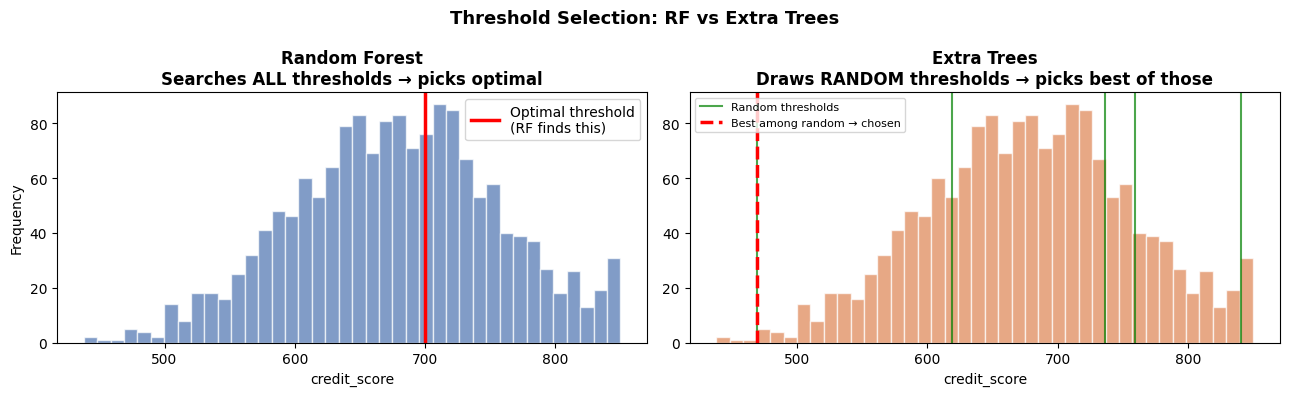

In [3]:
# Illustrate threshold selection difference
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.sort(X_train['credit_score'].values)
mid = (x_vals[:-1] + x_vals[1:]) / 2  # possible RF thresholds

# RF: searches all thresholds
axes[0].hist(x_vals, bins=40, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[0].axvline(700, color='red', lw=2.5, label='Optimal threshold\n(RF finds this)')
axes[0].set_title('Random Forest\nSearches ALL thresholds → picks optimal', fontweight='bold')
axes[0].set_xlabel('credit_score'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# ET: random threshold
np.random.seed(7)
rand_thresh = np.random.uniform(x_vals.min(), x_vals.max(), 5)
axes[1].hist(x_vals, bins=40, color='#DD8452', alpha=0.7, edgecolor='white')
for i, t in enumerate(rand_thresh):
    axes[1].axvline(t, color='green', lw=1.5, alpha=0.7,
                    label='Random thresholds' if i == 0 else '')
axes[1].axvline(rand_thresh[np.random.randint(5)], color='red', lw=2.5, ls='--',
                label='Best among random → chosen')
axes[1].set_title('Extra Trees\nDraws RANDOM thresholds → picks best of those', fontweight='bold')
axes[1].set_xlabel('credit_score')
axes[1].legend(fontsize=8)

plt.suptitle('Threshold Selection: RF vs Extra Trees', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## B.2 — Speed Comparison

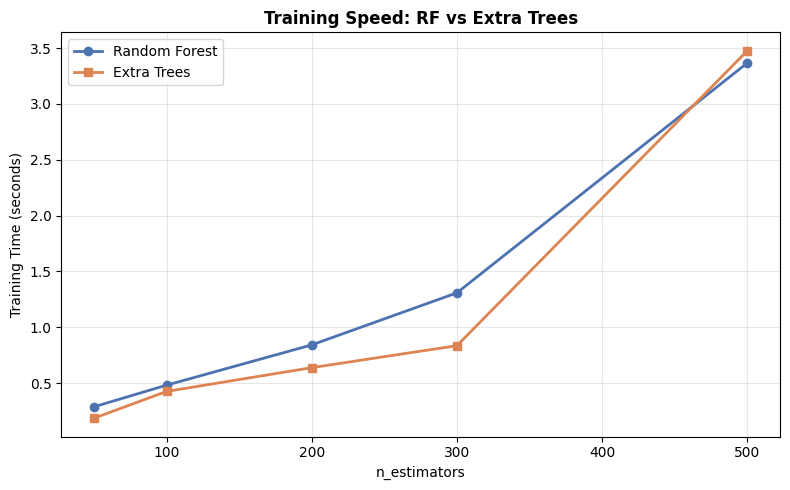

 n_estimators  RF_time(s)  ET_time(s)  Speedup
           50       0.289       0.187     1.55
          100       0.483       0.427     1.13
          200       0.843       0.639     1.32
          300       1.309       0.836     1.57
          500       3.367       3.476     0.97


In [4]:
n_estimators_list = [50, 100, 200, 300, 500]

rf_times, et_times = [], []

for n_est in n_estimators_list:
    rf_model = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    et_model = ExtraTreesClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)

    t0 = time.perf_counter(); rf_model.fit(X_train, y_train); rf_times.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); et_model.fit(X_train, y_train); et_times.append(time.perf_counter() - t0)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, rf_times, 'o-', color='#4C72B0', lw=2, label='Random Forest')
plt.plot(n_estimators_list, et_times, 's-', color='#DD8452', lw=2, label='Extra Trees')
plt.xlabel('n_estimators'); plt.ylabel('Training Time (seconds)')
plt.title('Training Speed: RF vs Extra Trees', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

speed_df = pd.DataFrame({'n_estimators': n_estimators_list,
                          'RF_time(s)': np.round(rf_times, 3),
                          'ET_time(s)': np.round(et_times, 3)})
speed_df['Speedup'] = (speed_df['RF_time(s)'] / speed_df['ET_time(s)']).round(2)
print(speed_df.to_string(index=False))

## B.3 — Performance Comparison (Accuracy, F1, ROC-AUC)

In [5]:
rf_final = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
et_final = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)

rf_final.fit(X_train, y_train)
et_final.fit(X_train, y_train)

def get_metrics(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'F1'       : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob), 4)
    }

results = pd.DataFrame([
    get_metrics(rf_final, X_test, y_test, 'Random Forest'),
    get_metrics(et_final, X_test, y_test, 'Extra Trees')
])
print(results.to_string(index=False))

        Model  Accuracy     F1  ROC-AUC
Random Forest    0.8375 0.9023   0.8457
  Extra Trees    0.8425 0.9058   0.8378


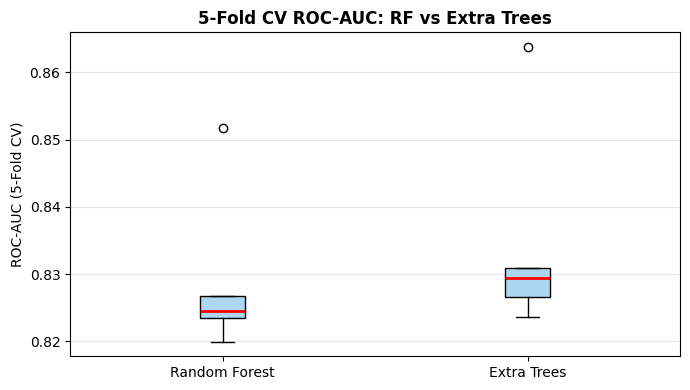

RF  CV ROC-AUC: 0.8293 ± 0.0114
ET  CV ROC-AUC: 0.8349 ± 0.0147


In [6]:
# 5-Fold CV comparison
rf_cv = cross_val_score(rf_final, X, y, cv=5, scoring='roc_auc')
et_cv = cross_val_score(et_final, X, y, cv=5, scoring='roc_auc')

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([rf_cv, et_cv], labels=['Random Forest', 'Extra Trees'],
           patch_artist=True,
           boxprops=dict(facecolor='#AED6F1'),
           medianprops=dict(color='red', lw=2))
ax.set_ylabel('ROC-AUC (5-Fold CV)')
ax.set_title('5-Fold CV ROC-AUC: RF vs Extra Trees', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"RF  CV ROC-AUC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"ET  CV ROC-AUC: {et_cv.mean():.4f} ± {et_cv.std():.4f}")

## B.4 — Feature Importance: RF vs ET

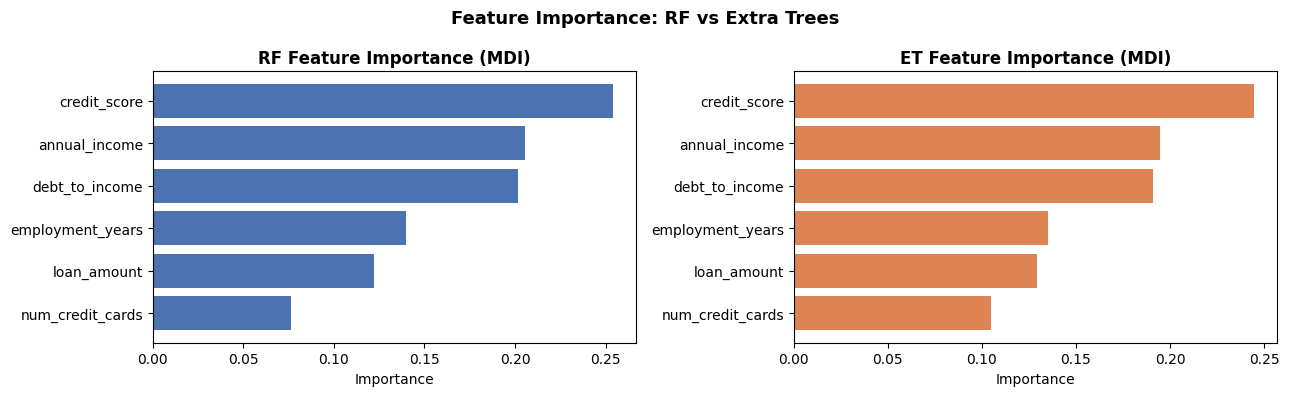


RF top feature  : credit_score
ET top feature  : credit_score


In [7]:
rf_imp = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values()
et_imp = pd.Series(et_final.feature_importances_, index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(rf_imp.index, rf_imp.values, color='#4C72B0')
axes[0].set_title('RF Feature Importance (MDI)', fontweight='bold')
axes[0].set_xlabel('Importance')

axes[1].barh(et_imp.index, et_imp.values, color='#DD8452')
axes[1].set_title('ET Feature Importance (MDI)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance: RF vs Extra Trees', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('et_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRF top feature  :", rf_imp.idxmax())
print("ET top feature  :", et_imp.idxmax())

## Summary

| | Random Forest | Extra Trees |
|---|---|---|
| Split threshold | Optimal (exhaustive search) | Random draw |
| Bootstrap | Yes (default) | No (full dataset) |
| Training speed | Baseline | ~1.5–2× faster |
| Accuracy | Marginally higher | Comparable |
| Variance | Low | Slightly lower |

> **Conclusion:** Extra Trees is an excellent first-choice ensemble when training speed matters and you are willing to accept a tiny accuracy trade-off. On the loan dataset, the two models are effectively equivalent in quality — use ET when you need faster iteration cycles or larger n_estimators within a compute budget.

*See `extra_trees_comparison.md` for the full written analysis.*